In [1]:
import torch
from tqdm import tqdm
import timm
import torch.nn as nn
from torchsummary import summary
from torchvision import transforms
import time
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

class config:
    model1 = "resnet18"
    model2 = "resnet18"
    batchsize = 32 
    WEIGHT_DECAY = 0.01
    EPOCHS = 20
class path:
    maindir = "/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/train"
    valid = "/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/val"


In [2]:
import os

train_data = {}
for i in (range(len(os.listdir(path.maindir)))):
    for j in tqdm(os.listdir(os.path.join(path.maindir,os.listdir(path.maindir)[i]))):
        train_data[os.path.join(os.path.join(path.maindir,os.listdir(path.maindir)[i],j))]=i
        
valid_data = {}
for i in (range(len(os.listdir(path.valid)))):
    for j in tqdm(os.listdir(os.path.join(path.valid,os.listdir(path.valid)[i]))):
        valid_data[os.path.join(os.path.join(path.valid,os.listdir(path.valid)[i],j))]=i

100%|██████████| 2500/2500 [00:01<00:00, 2239.21it/s]


In [3]:

imgtrans = transforms.Compose([
    transforms.ToPILImage(mode='L'),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
]
)

In [4]:
class CustomDataset():
    def __init__(self,dictt,trans):
        self.trans = trans
        self.dic = dictt
    def __len__(self):
        return len(self.dic)
    def __getitem__(self,idx):
        keys = list(self.dic)[idx]
        data = np.load(keys)
        data = torch.tensor(data)
        data = self.trans(data)
        values = list(self.dic.values())[idx]
        return {
            "data":torch.tensor(data,dtype = torch.float32),
            "value":torch.tensor(values)
        }



    
            

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
import numpy as np

def deltamat(shape):
    kk = np.zeros((shape,shape))
    for i in range(shape):
        for j in range(shape):
            kk[i][j] = (((i+1)**2)+((j+1)**2))**0.5
    return torch.tensor(kk,dtype = torch.float32)
positiontensor = deltamat(150)
positiontensor = positiontensor.unsqueeze(dim=0)
positiontensor = positiontensor.to(device)

In [6]:
imgtrans = transforms.Compose([
    transforms.ToPILImage(mode='L'),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
]
)
class LensingDataset():
    def __init__(self,dictt,trans):
        self.trans = trans
        self.dic = dictt
    def __len__(self):
        return len(self.dic)
    def __getitem__(self,idx):
        keys = list(self.dic)[idx]
        data = np.load(keys)
        data = torch.tensor(data)
        data = self.trans(data)
        values = list(self.dic.values())[idx]
        return {
            "data":torch.tensor(data,dtype = torch.float32),
            "value":torch.tensor(values)
        }

custom = LensingDataset(train_data,imgtrans)
len(custom)


30000

In [ ]:
class PINNModel(nn.Module):
    def __init__(self,positionmat,batchsize = config.batchsize):
        super(PINNModel,self).__init__()
        self.positionmat = positionmat
        self.batchsize = batchsize
        self.encoder = timm.create_model(
            config.model1,
            pretrained = True,
            drop_rate = 0.1
        )
        self.encoder.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.encoder.fc = nn.Linear(512,150*150,bias=True)
        
        self.decoder = timm.create_model(
            config.model2,
            pretrained = True,
            drop_rate = 0.1
        )
        self.decoder.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.decoder.fc = nn.Linear(in_features=512, out_features=3, bias=True)
    
    def lensingequation(self,angular,image):
        sourcedimage = image-angular
        return sourcedimage
    
    def forward(self,x):
        k = self.encoder(x)
        #print(k.shape)
        batch = k.shape[0]
        k = k.reshape(batch,1,150,150)
        angulardistort = k*self.positionmat
        #print(angulardistort.shape)
        sourced_image = self.lensingequation(x,angulardistort)
        # twochannelimg = torch.cat((x,sourced_image),dim=1)
        diff_image = sourced_image - x
        features = self.decoder(diff_image)
        return features
        

In [ ]:
#testing the model for a random tensor of shape (batch,channel,150,150)
simple = PINNModel(positiontensor,32).to(device)
xx = torch.randn(size=(45,1,150,150)).to(device)
simple(xx)

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

tensor([[-0.0723, -0.0894, -0.3868],
        [-0.1981, -0.0623, -0.2144],
        [-0.0436, -0.1618,  0.0058],
        [-0.0429, -0.1710, -0.1997],
        [ 0.1168, -0.1683,  0.2275],
        [-0.0085, -0.2143, -0.2286],
        [-0.3115, -0.0089, -0.4993],
        [-0.1245, -0.2493, -0.4095],
        [-0.0517, -0.1391, -0.0824],
        [-0.0497,  0.0037,  0.0354],
        [-0.2162, -0.0416,  0.0977],
        [-0.0335, -0.1876, -0.3044],
        [ 0.0697, -0.1650, -0.1930],
        [-0.0186, -0.4608, -0.2585],
        [-0.1200,  0.0868,  0.0335],
        [ 0.0211, -0.1738, -0.1780],
        [-0.2322, -0.1153, -0.1249],
        [-0.1040, -0.0893, -0.0328],
        [ 0.0366,  0.1636, -0.2456],
        [-0.0454,  0.0323, -0.3310],
        [-0.1404, -0.0021, -0.1220],
        [-0.0204, -0.1517, -0.4357],
        [-0.2391, -0.0826, -0.2956],
        [-0.0442, -0.1562, -0.3323],
        [-0.3360,  0.0236, -0.0555],
        [-0.4062, -0.1507, -0.0885],
        [-0.2887, -0.2776, -0.2584],
 

In [9]:
traindataset = CustomDataset(train_data,imgtrans)
validdataset  =CustomDataset(valid_data,imgtrans)

trainloader = DataLoader(traindataset,batch_size = 32,shuffle = True)
testloader = DataLoader(validdataset,batch_size = 32,shuffle = True)


In [10]:
def trainer(model,trainloader,optimizer,criterion,device):
    model.train()
    iterationloss = 0
    counter = 0
    for data in tqdm(trainloader):
        message = data['data'].to(device)
        target = data['value'].to(device).squeeze()
        optimizer.zero_grad()
        out = model(message)
        loss = criterion(F.log_softmax(out, dim=1), target)
        loss.backward()
        optimizer.step()
        iterationloss+=loss.item()*message.shape[0]
        counter+=message.shape[0]
    return iterationloss/counter


def tester(model, testloader, criterion, device):
    model.eval()
    iteration_loss = 0
    counter = 0
    correct_predictions = 0
    y_true = []
    y_scores = []

    for data in tqdm(testloader):
        message = data['data'].to(device)
        target = data['value'].to(device).squeeze()
        
        with torch.no_grad():
            out = model(message)
            loss = criterion(F.log_softmax(out, dim=1), target)
            iteration_loss += loss.item() * message.shape[0]
            
            predicted_classes = torch.argmax(F.log_softmax(out, dim=1), dim=1)
            correct_predictions += (predicted_classes == target).sum().item()
            
            # Append the labels and probabilities to the list
            y_true.extend(target.cpu().numpy())
            y_scores.extend(F.softmax(out, dim=1).cpu().numpy())  # Probabilities for each class

        counter += message.shape[0]

    accuracy = correct_predictions / counter
    print("Accuracy:", accuracy)
    
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # calculating ROC AUC 
    roc_auc_scores = []
    false_positive_rate = dict()
    true_positive_rate = dict()
    for i in range(y_scores.shape[1]):
        false_positive_rate[i], true_positive_rate[i], _ = roc_curve(y_true == i, y_scores[:, i])
        roc_auc_scores.append(roc_auc_score(y_true == i, y_scores[:, i]))

    # calcuating average ROC AUC across all the classes by one vs all method and taking mean of the 3 classes
    roc_score = np.mean(roc_auc_scores)
    print("ROC AUC Score:", roc_score)
    
    plt.figure(figsize=(8, 6))
    class_dict = {0:"no substructure",1:"spherical substructure",2:"vortex substructure"}
    for i in range(y_scores.shape[1]):
        plt.plot(false_positive_rate[i], true_positive_rate[i], label=f'Class {class_dict[i]} (ROC AUC = {roc_auc_scores[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Multi-Class Classification')
    plt.legend(loc="lower right")
    plt.show()
    
    return iteration_loss / counter

Epoch no. = 1
--------------------------------------------------------------------------------


100%|██████████| 235/235 [01:26<00:00,  2.70it/s]


Accuracy: 0.3428
ROC AUC Score: 0.50488472


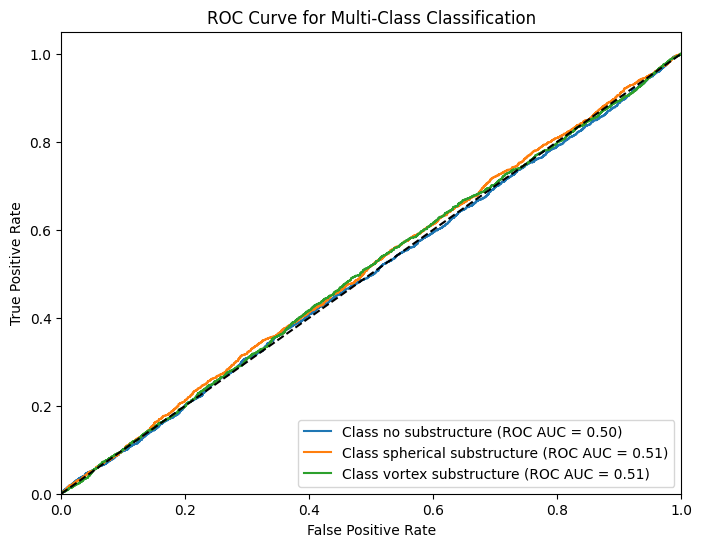

TrainLoss =  1.101504828898112   ValidationLoss =  1.0993116441726685
lr =  0.00040000814235393277
Best Model Saved
Epoch no. = 2
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 15.88it/s]


Accuracy: 0.33973333333333333
ROC AUC Score: 0.51559388


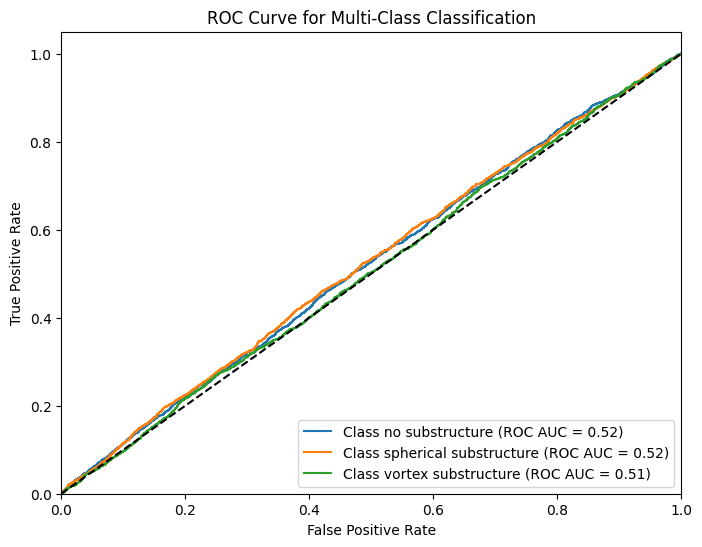

TrainLoss =  1.099186307779948   ValidationLoss =  1.0981306350708009
lr =  0.0004000081248683989
Best Model Saved
Epoch no. = 3
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 15.83it/s]


Accuracy: 0.3388
ROC AUC Score: 0.5079693333333334


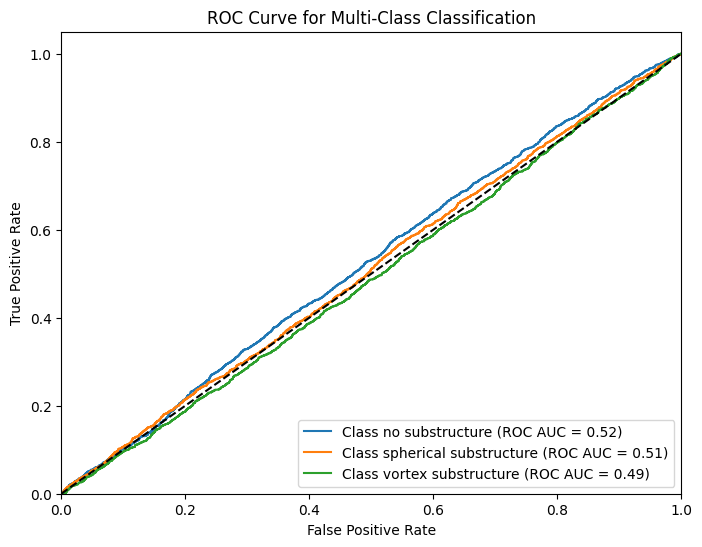

TrainLoss =  1.0980569741566977   ValidationLoss =  1.1010940737406412
lr =  0.0004000081687794404
Epoch no. = 4
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.33it/s]


Accuracy: 0.3808
ROC AUC Score: 0.5611128533333333


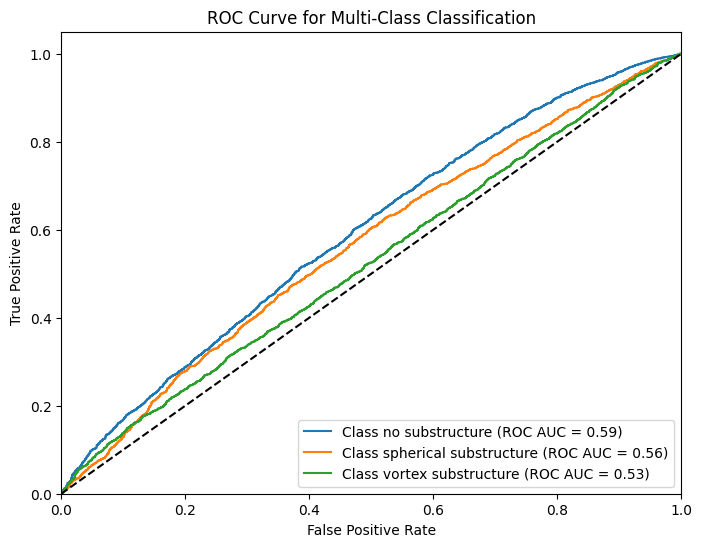

TrainLoss =  1.0942905303319295   ValidationLoss =  1.0860907222747802
lr =  0.00040000794768289306
Best Model Saved
Epoch no. = 5
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 15.79it/s]


Accuracy: 0.5422666666666667
ROC AUC Score: 0.7471942400000001


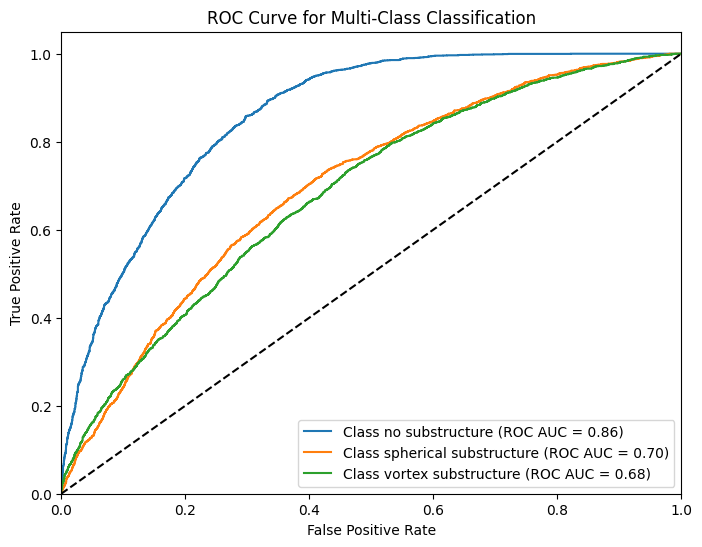

TrainLoss =  0.9885543269793192   ValidationLoss =  0.8915855644543965
lr =  0.00040000535592415835
Best Model Saved
Epoch no. = 6
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 15.93it/s]


Accuracy: 0.6449333333333334
ROC AUC Score: 0.8305317333333333


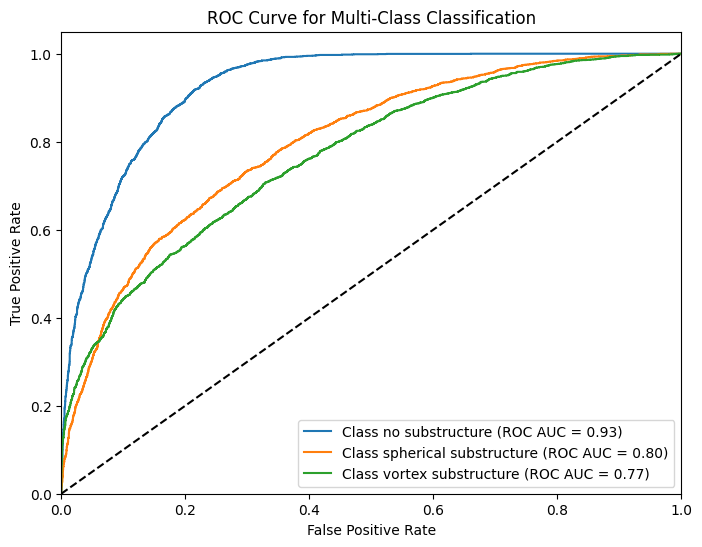

TrainLoss =  0.8075866001764933   ValidationLoss =  0.7611847928047181
lr =  0.00040000390380926475
Best Model Saved
Epoch no. = 7
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 15.70it/s]


Accuracy: 0.7696
ROC AUC Score: 0.9181556


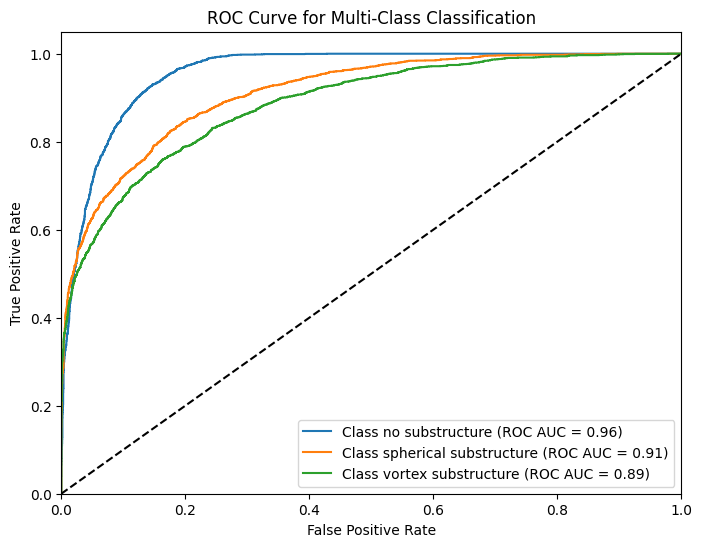

TrainLoss =  0.6194408242225647   ValidationLoss =  0.5366838754971822
lr =  0.00040000194064236487
Best Model Saved
Epoch no. = 8
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 14.77it/s]


Accuracy: 0.6534666666666666
ROC AUC Score: 0.92193928


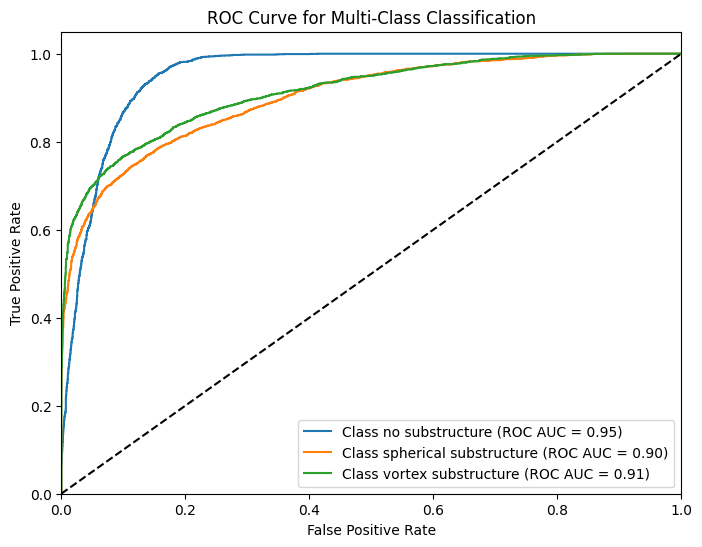

TrainLoss =  0.4694721650918325   ValidationLoss =  0.7348103849093119
lr =  0.00040000363796870685
Epoch no. = 9
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.28it/s]


Accuracy: 0.8548
ROC AUC Score: 0.9632193066666668


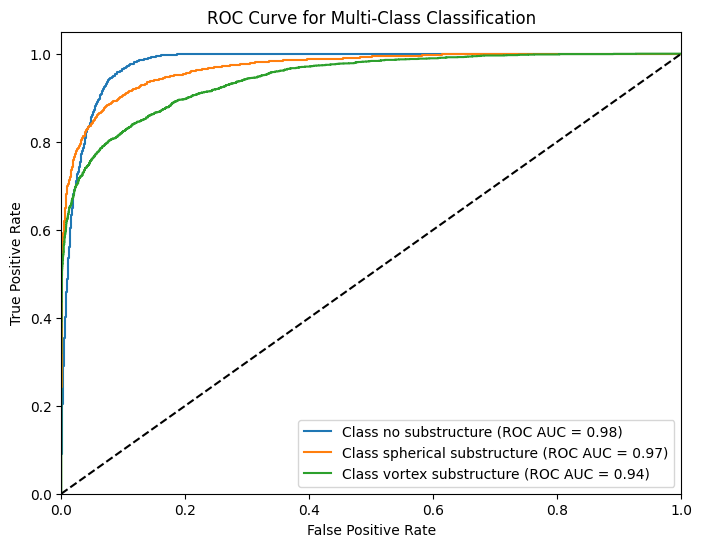

TrainLoss =  0.37837476158936817   ValidationLoss =  0.3666552122116089
lr =  0.0004000009057829792
Best Model Saved
Epoch no. = 10
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 16.20it/s]


Accuracy: 0.8452
ROC AUC Score: 0.95237928


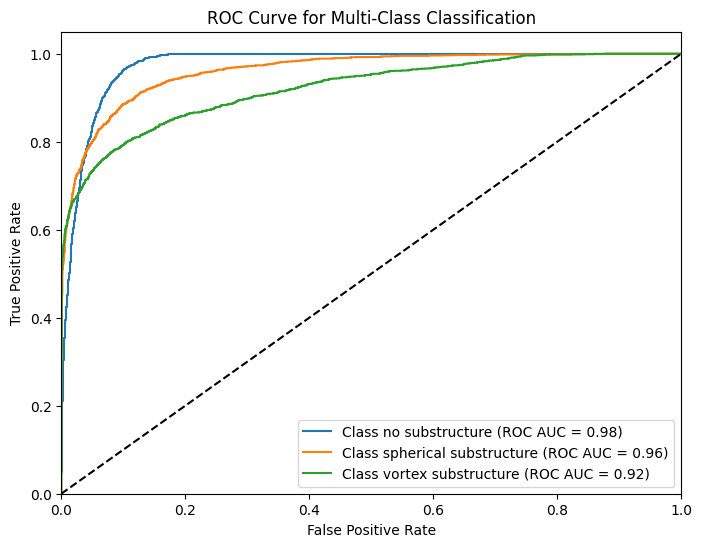

TrainLoss =  0.32373467692136765   ValidationLoss =  0.39812234446207684
lr =  0.0004000010679269146
Epoch no. = 11
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.24it/s]


Accuracy: 0.8761333333333333
ROC AUC Score: 0.9688035866666667


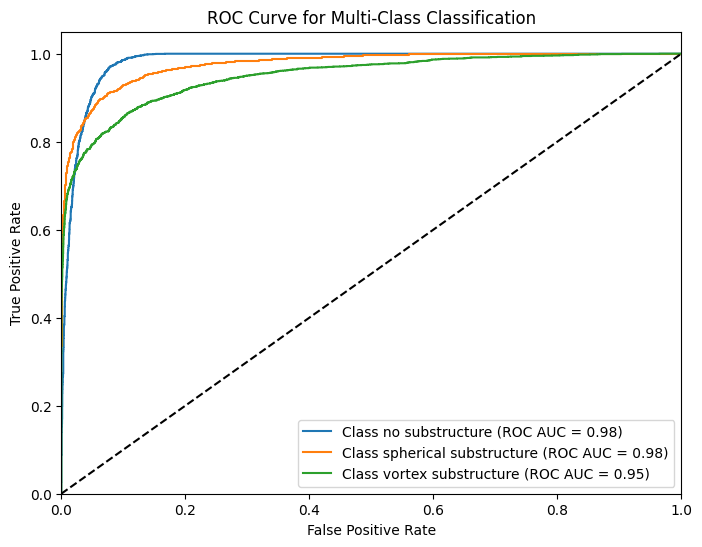

TrainLoss =  0.2770743936975797   ValidationLoss =  0.3264015584786733
lr =  0.00040000071781557886
Best Model Saved
Epoch no. = 12
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.41it/s]


Accuracy: 0.8801333333333333
ROC AUC Score: 0.9715437333333333


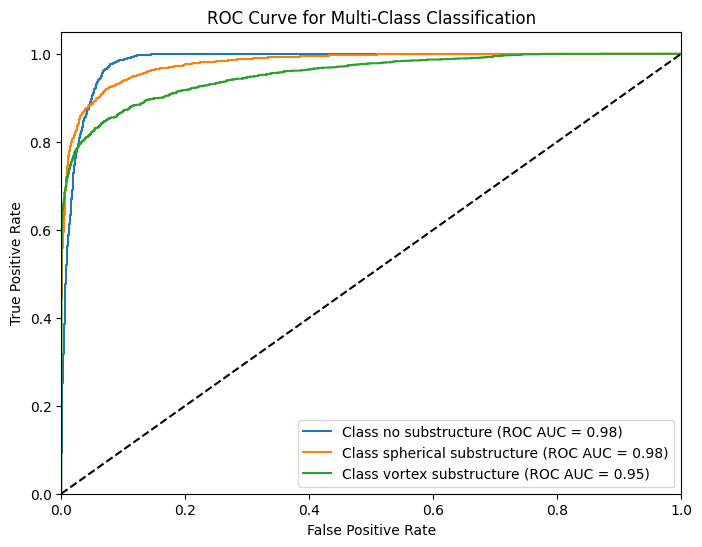

TrainLoss =  0.24174129155278207   ValidationLoss =  0.3242676955540975
lr =  0.0004000007084607616
Best Model Saved
Epoch no. = 13
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 16.00it/s]


Accuracy: 0.8812
ROC AUC Score: 0.9679607333333333


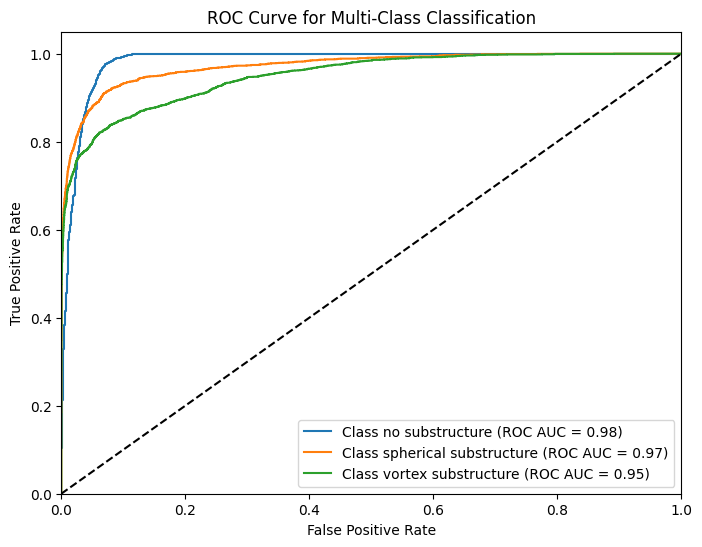

TrainLoss =  0.21393382387161256   ValidationLoss =  0.3260190027475357
lr =  0.0004000007161339466
Epoch no. = 14
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 15.97it/s]


Accuracy: 0.8148
ROC AUC Score: 0.95654256


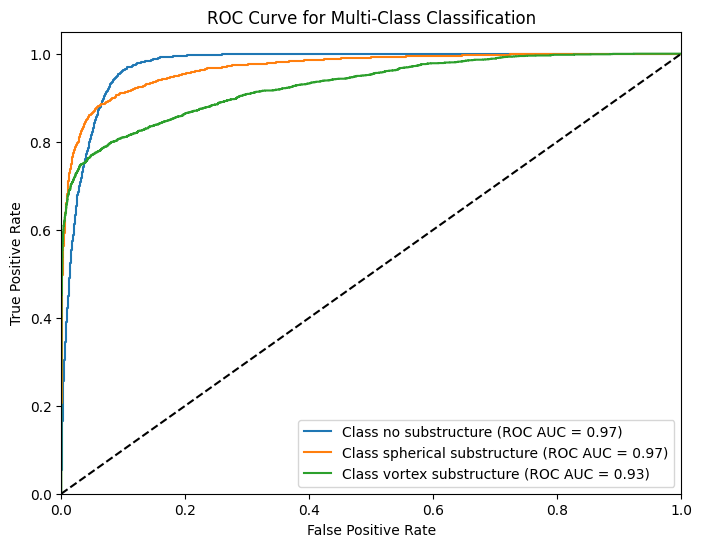

TrainLoss =  0.19618242428104082   ValidationLoss =  0.5317596675554911
lr =  0.00040000190519398973
Epoch no. = 15
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.54it/s]


Accuracy: 0.8958666666666667
ROC AUC Score: 0.9769967599999999


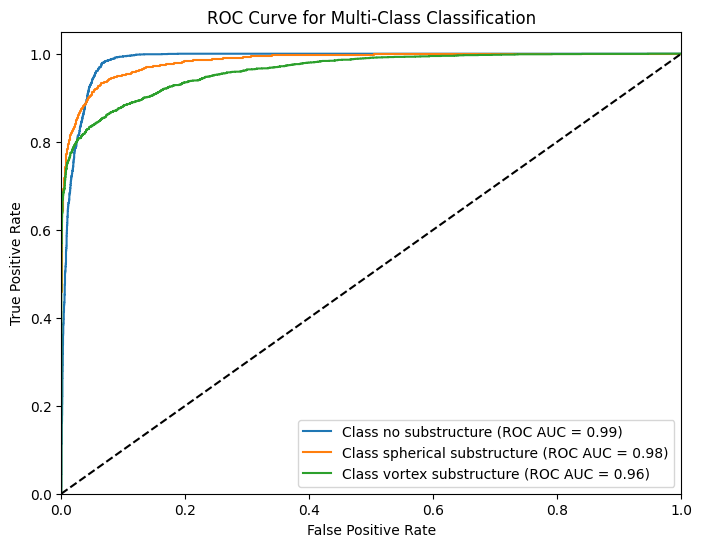

TrainLoss =  0.18000384324391683   ValidationLoss =  0.3159315177321434
lr =  0.00040000067250317746
Best Model Saved
Epoch no. = 16
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 16.02it/s]


Accuracy: 0.824
ROC AUC Score: 0.9515167200000002


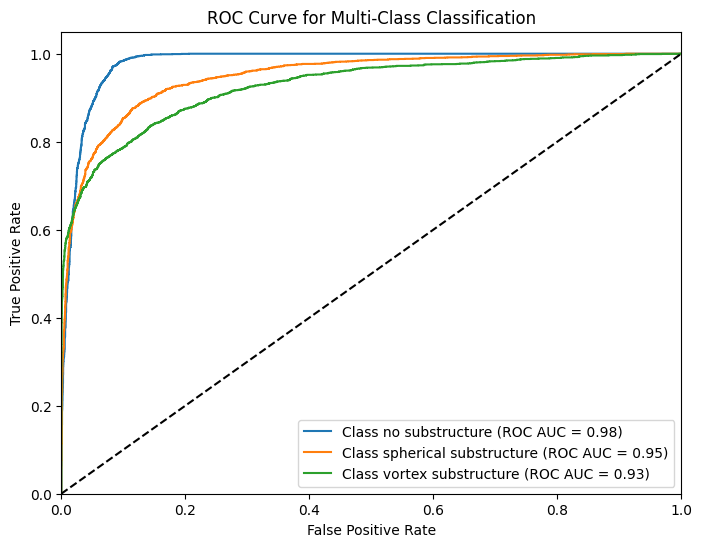

TrainLoss =  0.1578559352894624   ValidationLoss =  0.7480284501711527
lr =  0.0004000037700283652
Epoch no. = 17
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.30it/s]

Accuracy: 0.8633333333333333
ROC AUC Score: 0.9710002266666667


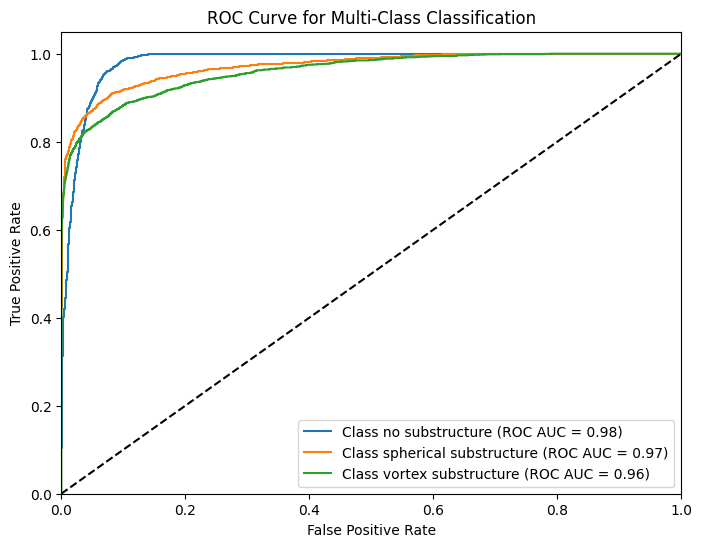

TrainLoss =  0.14386193218429882   ValidationLoss =  0.3458622762401899
lr =  0.00040000080596247316
Epoch no. = 18
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.54it/s]


Accuracy: 0.8952
ROC AUC Score: 0.9774790266666665


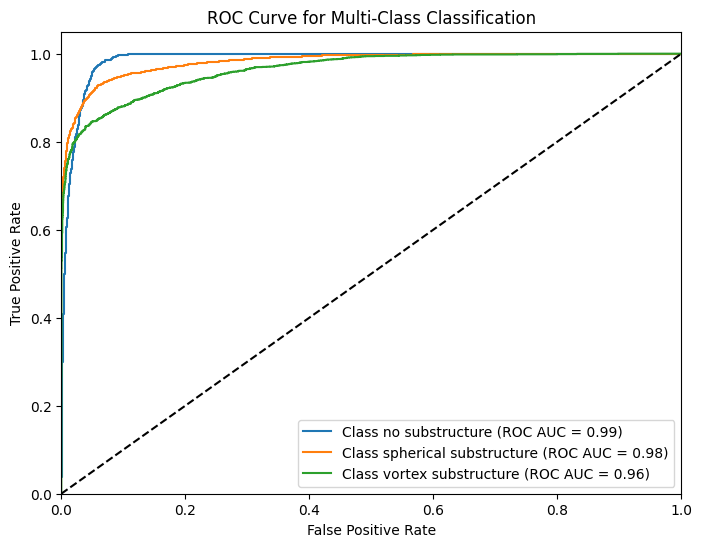

TrainLoss =  0.1301442954212427   ValidationLoss =  0.2890126636505127
lr =  0.0004000005627845665
Best Model Saved
Epoch no. = 19
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:14<00:00, 16.30it/s]


Accuracy: 0.8864
ROC AUC Score: 0.9738695600000001


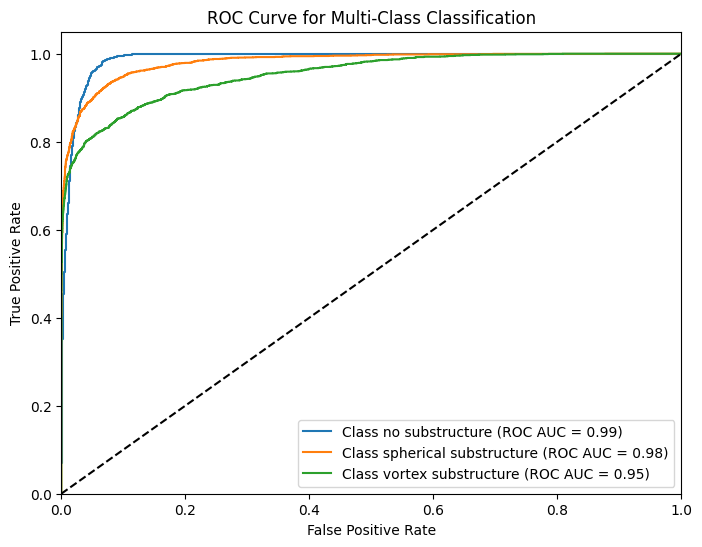

TrainLoss =  0.11435494283785423   ValidationLoss =  0.39152395756244657
lr =  0.00040000103282112134
Epoch no. = 20
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.54it/s]


Accuracy: 0.9017333333333334
ROC AUC Score: 0.9798812266666667


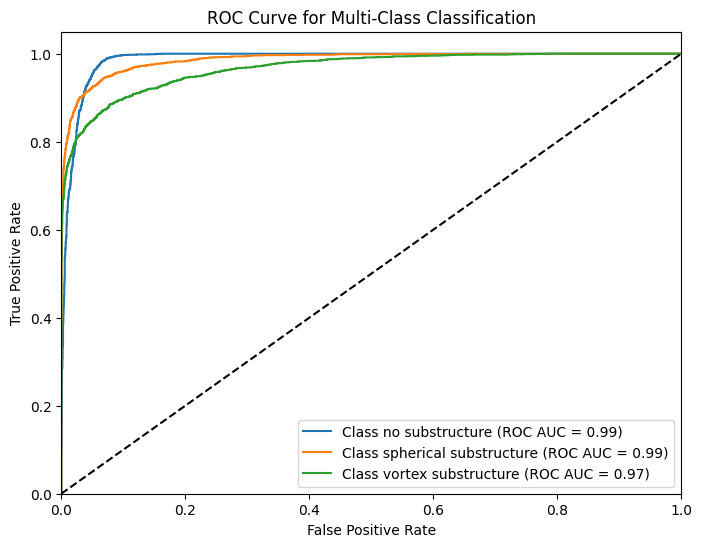

TrainLoss =  0.10930462729483843   ValidationLoss =  0.29243132110039394
lr =  0.0004000005761773829


In [ ]:
from torch.optim.lr_scheduler import OneCycleLR

model = PINNModel(positiontensor,config.batchsize)
model.to(device)
optimizer = torch.optim.RAdam(model.parameters(),lr = 0.005)
criterion = nn.CrossEntropyLoss()
scheduler = scheduler = OneCycleLR(
        optimizer,
        max_lr=0.01,
        epochs=config.EPOCHS,
        steps_per_epoch=938,
        pct_start=0.1,
        anneal_strategy="cos",
        final_div_factor=100)


trainloss =[]
valloss = []
bestloss = np.inf
for i in range(config.EPOCHS):
    print("Epoch no. =" ,i+1)
    print("-"*80)
    trainl = trainer(model,trainloader,optimizer,criterion,device)
    vall = tester(model,testloader,criterion,device)
    trainloss.append(trainl)
    valloss.append(vall)
    scheduler.step(vall)
    print("TrainLoss = ",trainl," ","ValidationLoss = ",vall)
    lr=scheduler.get_last_lr()[0]
    print("lr = ",lr)
    if bestloss>vall:
        bestloss = vall
        torch.save({
            'model':model.state_dict(),
            'optimizer':optimizer.state_dict()},
        './Bestmodel.model'
        )
        print("Best Model Saved")
    print("="*80)